# Headless Deer Validation

This notebook compares predictions on images where the deer's head is missing or only partly visible.
The CSV does not contain a head-visibility label, so candidate images must be selected manually first.

Run the cells from top to bottom. No training is performed.

## 1. Load data and model

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms as T
import timm

ROOT = Path.cwd()
CSV_PATH = ROOT / 'Snapshot_WI-Oh_Deer_data-v1.csv'
PHOTOS_DIR = ROOT / 'Snapshot_WI-Oh_Deer_Photos' / 'Deer'
MODEL_PATH = ROOT / 'oh_deer_model.pt'
DEVICE = torch.device('cpu')

df = pd.read_csv(CSV_PATH)

def normalize_label(value, positive_keys, negative_keys):
    text = str(value).strip().lower()
    if any(key in text for key in positive_keys):
        return 1
    if any(key in text for key in negative_keys):
        return 0
    return None

df['true_antler'] = df['antler_status'].map(
    lambda value: normalize_label(value, ['antlered', 'yes', 'true', 'buck'], ['antlerless', 'no', 'false', 'doe'])
)
df['true_age'] = df['age_status'].map(
    lambda value: normalize_label(value, ['young', 'fawn', 'juvenile'], ['adult', 'mature'])
)
df = df.dropna(subset=['true_antler', 'true_age']).reset_index(drop=True)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
MODEL_NAME = checkpoint.get('model_name', 'efficientnet_b0')
IMG_SIZE = int(checkpoint.get('img_size', 224))
THRESHOLD_ANTLER = float(checkpoint.get('threshold_antler', 0.5))
THRESHOLD_AGE = float(checkpoint.get('threshold_age', 0.5))

print('Rows:', len(df))
print('Model:', MODEL_NAME)
print('Image size:', IMG_SIZE)

Rows: 4880
Model: efficientnet_b0
Image size: 224


In [5]:
class MultiTaskDeer(nn.Module):
    def __init__(self, backbone='efficientnet_b0'):
        super().__init__()
        self.backbone = timm.create_model(
            backbone, pretrained=False, num_classes=0, global_pool='avg'
        )
        features = self.backbone.num_features
        self.dropout = nn.Dropout(0.3)
        self.head_antler = nn.Linear(features, 2)
        self.head_age = nn.Linear(features, 2)

    def forward(self, x):
        features = self.dropout(self.backbone(x))
        return self.head_antler(features), self.head_age(features)

model = MultiTaskDeer(MODEL_NAME).to(DEVICE)
model.load_state_dict(checkpoint['state_dict'])
model.eval()
transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
print('Model loaded successfully.')

Model loaded successfully.


## 2. Create a random candidate sheet

Look through these images and identify cases where the head is missing or only partly visible. Then copy their filenames into the next cell.

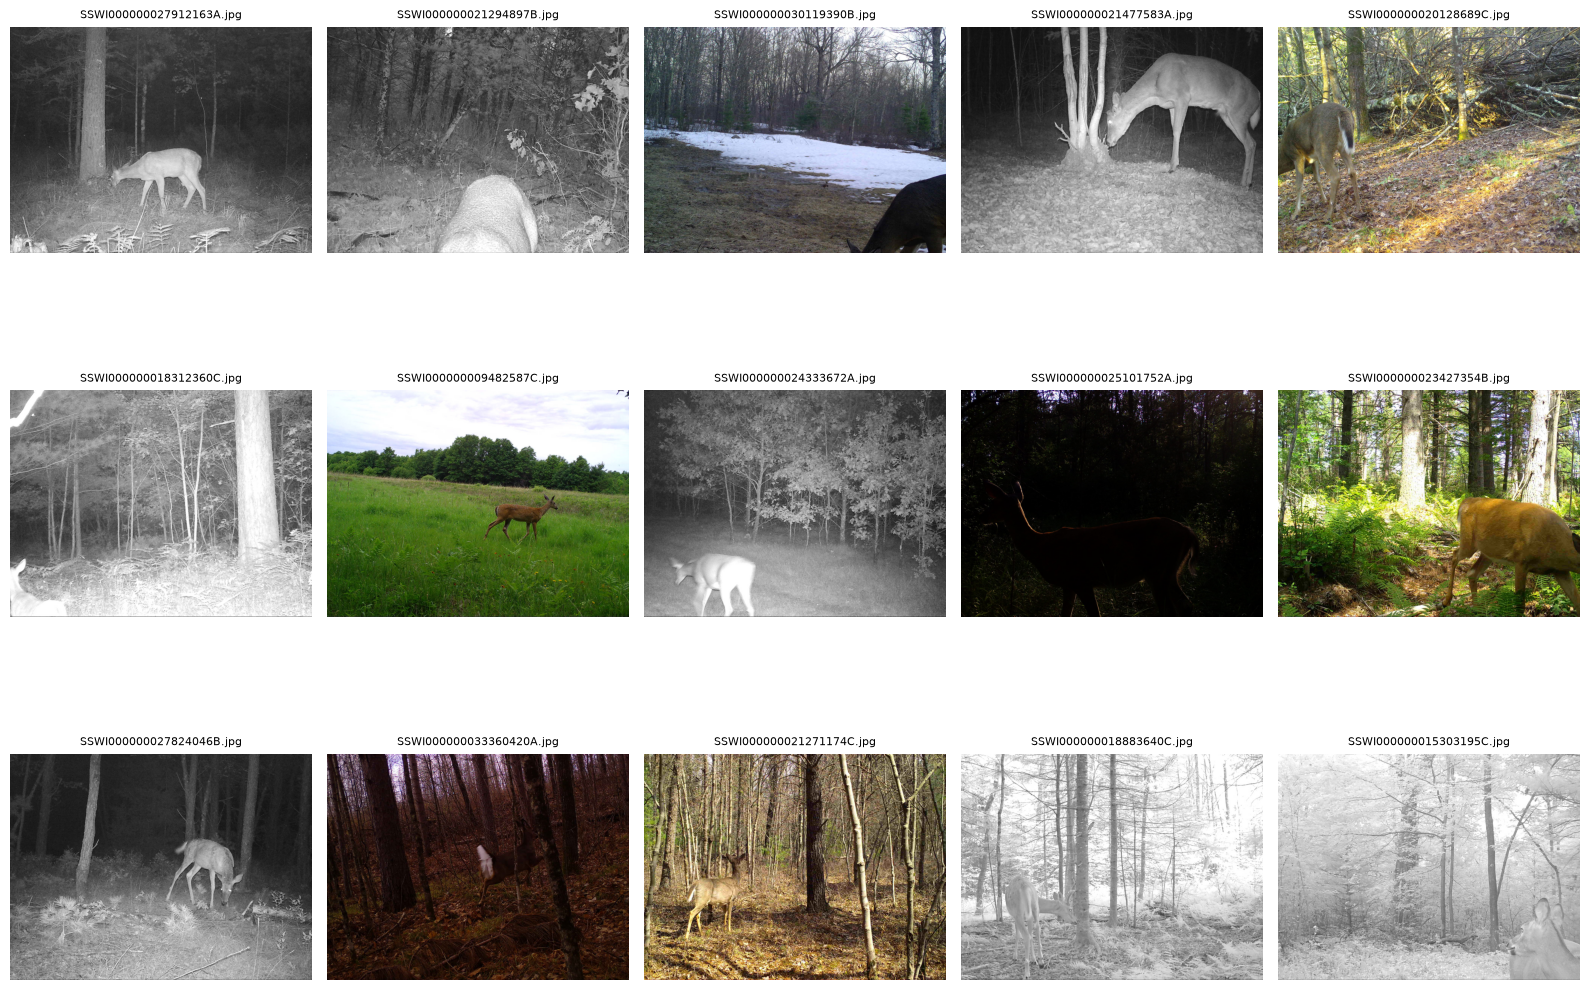

Candidate filenames, one per line:
01. SSWI000000027912163A.jpg
02. SSWI000000021294897B.jpg
03. SSWI000000030119390B.jpg
04. SSWI000000021477583A.jpg
05. SSWI000000020128689C.jpg
06. SSWI000000018312360C.jpg
07. SSWI000000009482587C.jpg
08. SSWI000000024333672A.jpg
09. SSWI000000025101752A.jpg
10. SSWI000000023427354B.jpg
11. SSWI000000027824046B.jpg
12. SSWI000000033360420A.jpg
13. SSWI000000021271174C.jpg
14. SSWI000000018883640C.jpg
15. SSWI000000015303195C.jpg

Copy the filenames of headless or partly headless images into the next cell.


In [57]:
CANDIDATE_COUNT = 15
candidate_rows = df.sample(CANDIDATE_COUNT, random_state=None)
fig, axes = plt.subplots(3, 5, figsize=(16, 12))
for axis, (_, row) in zip(axes.flat, candidate_rows.iterrows()):
    path = PHOTOS_DIR / str(row['filename'])
    image = Image.open(path).convert('RGB')
    axis.imshow(image)
    axis.axis('off')
    axis.set_title(str(row['filename']), fontsize=8)
plt.tight_layout()
plt.show()

print('Candidate filenames, one per line:')
for index, filename in enumerate(candidate_rows['filename'], start=1):
    print(f'{index:02d}. {filename}')
print('\nCopy the filenames of headless or partly headless images into the next cell.')

## 3. Select the headless images

Selected images: 12


,filename,true_antler,pred_antler,antler_probability,true_age,pred_age,age_probability,antler_correct,age_correct
0,SSWI000000028797398B.jpg,Antlerless,Antlered,0.7051,Young,Adult,0.1612,False,False
1,SSWI000000017591912B.jpg,Antlerless,Antlerless,0.2367,Young,Young,0.9057,True,True
2,SSWI000000024754975B.jpg,Antlered,Antlered,0.9885,Adult,Adult,0.0419,True,True
3,SSWI000000010749337B.jpg,Antlered,Antlered,0.7357,Adult,Adult,0.3002,True,True
4,SSWI000000011220613C.jpg,Antlered,Antlered,0.7867,Adult,Adult,0.3473,True,True
5,SSWI000000021294897B.jpg,Antlerless,Antlerless,0.2933,Adult,Young,0.5426,True,False
6,SSWI000000021295439A.jpg,Antlerless,Antlerless,0.4596,Adult,Adult,0.0407,True,True
7,SSWI000000029184493C.jpg,Antlerless,Antlered,0.6492,Adult,Young,0.6445,False,False
8,SSWI000000009875169A.jpg,Antlerless,Antlerless,0.1652,Adult,Young,0.9043,True,False
9,SSWI000000025843738C.jpg,Antlerless,Antlerless,0.0680,Adult,Young,0.6127,True,False


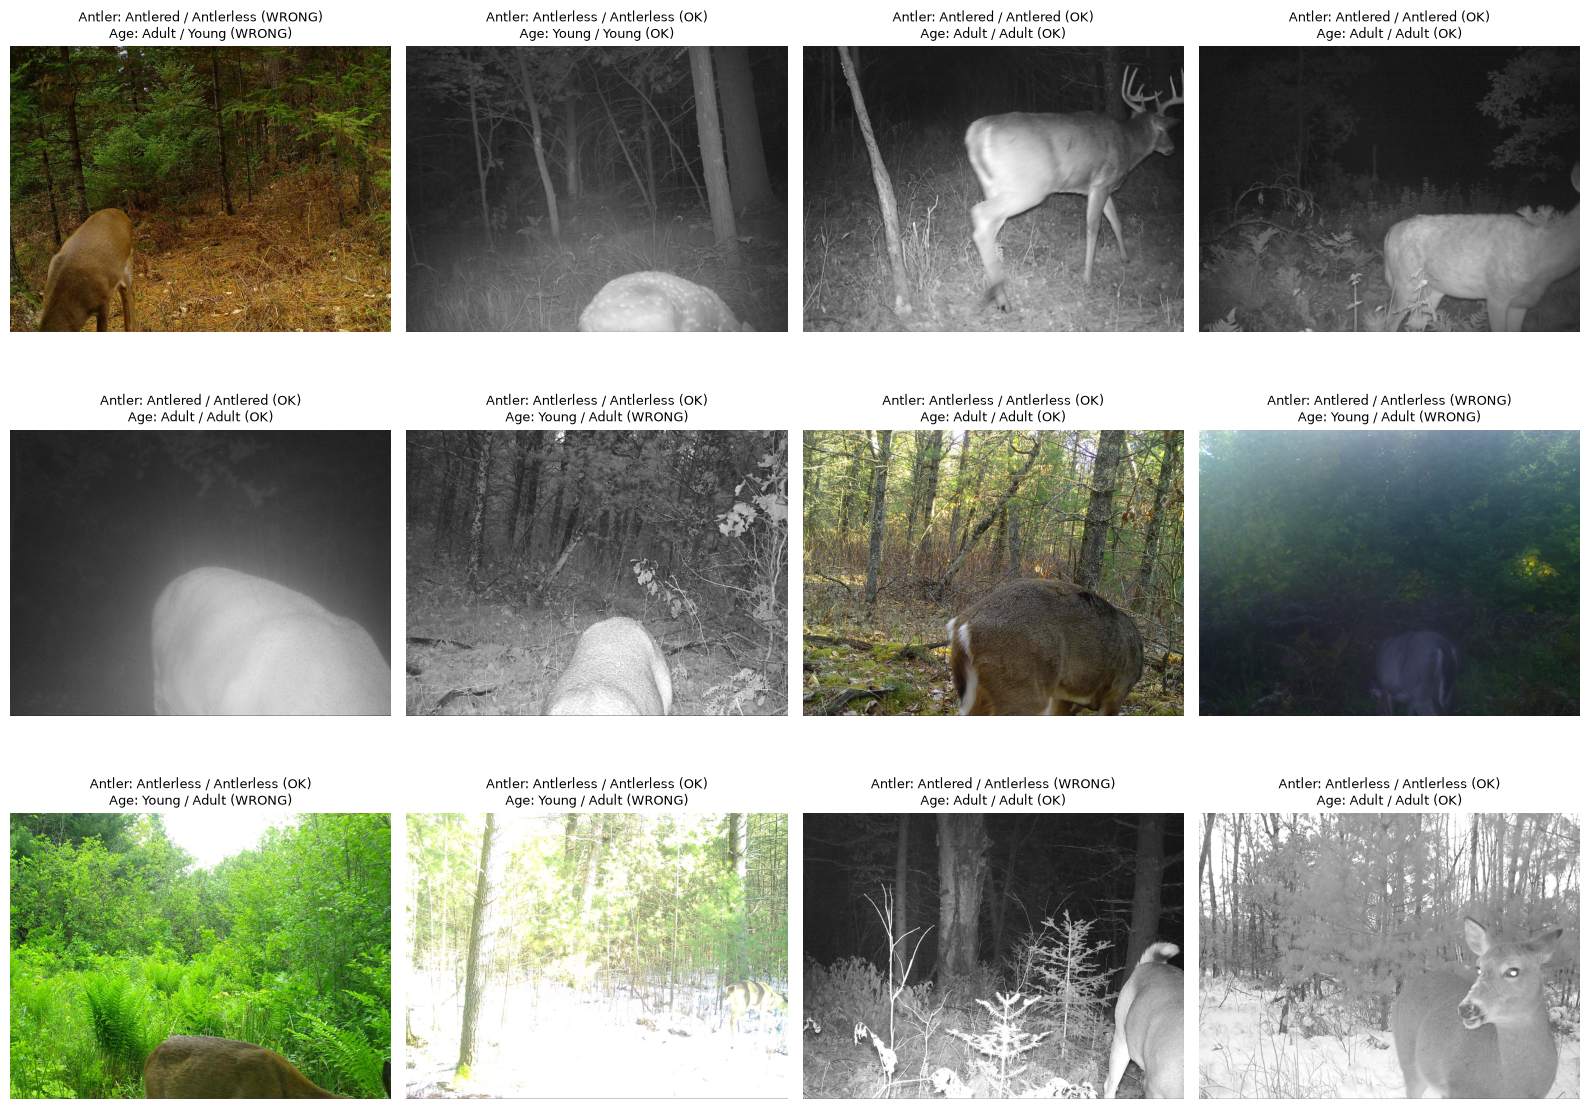

In [58]:
HEADLESS_FILENAMES = [
 'SSWI000000010749337B.jpg',
 'SSWI000000013076874C.jpg',
 'SSWI000000009875169A.jpg',
 'SSWI000000021295439A.jpg',
 'SSWI000000011220613C.jpg',
 'SSWI000000024754975B.jpg',
 'SSWI000000033875802C.jpg',
 'SSWI000000028797398B.jpg',
 'SSWI000000025843738C.jpg',
 'SSWI000000029184493C.jpg',
 'SSWI000000017591912B.jpg',
 'SSWI000000021294897B.jpg',
]

selected_rows = df[df['filename'].isin(HEADLESS_FILENAMES)].copy()
missing = sorted(set(HEADLESS_FILENAMES) - set(selected_rows['filename']))
if missing:
    print('These filenames were not found in the CSV:', missing)
print('Selected images:', len(selected_rows))

@torch.no_grad()
def predict_row(row):
    path = PHOTOS_DIR / str(row['filename'])
    image = Image.open(path).convert('RGB')
    tensor = transform(image).unsqueeze(0).to(DEVICE)
    antler_logits, age_logits = model(tensor)
    antler_probability = float(antler_logits.softmax(1)[0, 1])
    age_probability = float(age_logits.softmax(1)[0, 1])
    return {
        'filename': row['filename'],
        'true_antler': 'Antlered' if row['true_antler'] else 'Antlerless',
        'pred_antler': 'Antlered' if antler_probability > THRESHOLD_ANTLER else 'Antlerless',
        'antler_probability': round(antler_probability, 4),
        'true_age': 'Young' if row['true_age'] else 'Adult',
        'pred_age': 'Young' if age_probability > THRESHOLD_AGE else 'Adult',
        'age_probability': round(age_probability, 4),
    }

headless_results = pd.DataFrame([predict_row(row) for _, row in selected_rows.iterrows()])
if len(headless_results):
    headless_results['antler_correct'] = headless_results['true_antler'] == headless_results['pred_antler']
    headless_results['age_correct'] = headless_results['true_age'] == headless_results['pred_age']
    display(headless_results)
else:
    print('HEADLESS_FILENAMES is empty. Select filenames in the previous cell first.')

if len(selected_rows):
    columns = 4
    rows = (len(selected_rows) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(16, 4 * rows), squeeze=False)
    for axis in axes.flat:
        axis.axis('off')
    for axis, (_, row) in zip(axes.flat, selected_rows.iterrows()):
        result = headless_results.loc[headless_results['filename'].eq(row['filename'])].iloc[0]
        image = Image.open(PHOTOS_DIR / str(row['filename'])).convert('RGB')
        axis.imshow(image)
        antler_mark = 'OK' if result['antler_correct'] else 'WRONG'
        age_mark = 'OK' if result['age_correct'] else 'WRONG'
        axis.set_title(
            f"Antler: {result['pred_antler']} / {result['true_antler']} ({antler_mark})\n"
            f"Age: {result['pred_age']} / {result['true_age']} ({age_mark})",
            fontsize=9,
        )
    plt.tight_layout()
    plt.show()